<img src="/root/capsule/data/resources/swdb_logo.jpg">  

<h1 align="center">Workshop SWDB 2026 </h1> 
<h3 align="center">Monday, August 24, 2026</h3> 

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Day 1: Data and Tools Overview</h2>


This tutorial provides a process for exploring a new dataset, including basic data access patterns and visualizations to build understanding. Along the way, we'll fill out a README documenting findings in the form of text descriptions, code snippets, and figures. 

Learning objectives 

- Navigate the structure and organization of a Neurodata Without Borders (NWB) file (`pynwb`)
- Select, align, and summarize neural and behavioral data, stimulus tables(`numpy`, `pandas`)
- Build visualizations to develop intuition about the data and perform sanity checks (`matplotlib`)
- Documenting relevant dataset details, especially in the age of LLM assistance

<h2>Process</h2>

Starting from a scientific question, the process is as follows:

1. Write down expectations of what data is available and needed for your question
2. Explore the data structure and vocabulary
3. Extract and inspect the data pieces you need
4. Create visualizations along the way, increasing in complexity 

The Allen Institute datasets are standardized to common core frameworks, so data access patterns roughly align across them, but each <b>dataset has idiosyncrasies</b>. Pay attention to the process and the skills, not necessarily the exact syntax or paths.


</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>V1 Deep Dive</h2>

Characterizing the relationship between neural function and connectivity is a central problem in neuroscience. In order to explore this relationship, visual responses from pan-excitatory neurons within an 800X800 um region of primary visual cortex were recorded, spanning all visual layers from pia to white matter. This includes ~50,000 neurons per mouse in 4 mice total, collected from 150 2-photon and 7 3-photon calcium imaging planes spaced by ~16 um (here were only sharing 2p data). This dataset will be used to examine the single-cell and population activity in primary visual cortex, and along with electron microscopic reconstruction from the same tissue, will serve as a valuable resource in studying the functional connectome in mouse cortex. A wide variety of visual stimuli were used to characterize neural responses, including windowed and full field drifting gratings, locally sparse noise, natural movies and natural images. 

You can find further documentation about this dataset (and other SWDB datasets) in the data book: https://allenswdb.github.io/physiology/ophys/V1DD/V1DD-overview.html  
</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Part 1: Write down data expectations  </h2>

**Data needs:**

| Category | What to look for |
| -------- | ------- |
| Neural activity | Is it raw or processed? (e.g. raw calcium videos vs. dF/F per ROI) |
| Stimulus | Stimulus tables |
| Behavior | Behavior tables (e.g. rewards, hits/misses), behavior timeseries (running, pupil) |
| Metadata | Animal and session information |

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Write down what data you expect this dataset to have, based on the documentation. Record it in the README.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Setup</h2>

</div>

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynwb

data_dir = '/data'

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Set up figure settings 
</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Part 2: Explore data structure and vocabulary </h2>

<h3> File organization </h3>

Start by exploring how the `/data` folder is laid out.

</div>

In [3]:
#  First, explore the /data folder organization.

# each project has a dataset folder 
# in V1DD, folders organized by subject ('subject_V1DD_Filtered') 
# each subject folder organized by session (25)
# each session contains an NWB file (nwb.zarr) and metadata jsons 

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Document the data organization in *V1DD_README.md*.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

#### Metadata

Rich metadata is collected for each data asset that gives information about the subject, session, instrument, and more. Accompanying each NWB file are a set of json files with metadata. This information is stored in a metadata database that is queryable and also viewable through the metadata portal. 

SWDB Data Portal: https://data.allenneuraldynamics.org/swdb 

For each project dataset, we've generated a metadata CSV file in the */data/metadata* folder with up-leveled fields scraped from the database. If there is further metadata information you need, the code to query the metadata database and generate the CSVs is in the */code/metadata* folder. 

</div>

In [4]:
# Inspect the metadata table 

# Each row corresponds to a session and each column contains different metadata fields. 
metadata = pd.read_csv(os.path.join(data_dir, 'metadata', 'V1DD_metadata.csv'))
metadata

,project_name,_id,name,subject_id,golden_mouse,genotype,date_of_birth,age,sex,modality,session_date,session_start_time,session_end_time,column,volume,depth,targeted_structure
0,V1 Deep Dive,5b6b926a-0771-4664-8053-c52fa0e56189,409828_2018-12-12_12-24-18_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,162,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-12,12:24:18.963730,13:24:27.772570,1,1,"[np.int64(130), np.int64(114), np.int64(98), n...",VISp
1,V1 Deep Dive,88412a4c-b448-4efb-9825-d785bd5b56ba,409828_2018-12-13_13-21-39_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,163,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-13,13:21:39.888000,14:21:12.698880,1,2,"[np.int64(226), np.int64(210), np.int64(194), ...",VISp
2,V1 Deep Dive,dac12127-2aed-4392-ae2f-4a57e1bf85e5,409828_2018-12-13_15-10-05_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,163,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-13,15:10:05.562960,16:09:36.222020,1,3,"[np.int64(322), np.int64(306), np.int64(290), ...",VISp
3,V1 Deep Dive,34d05e9e-ee69-412b-b98d-47dd9d79082e,409828_2018-12-14_13-14-42_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,164,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-14,13:14:42.634500,14:15:00.029230,1,4,"[np.int64(418), np.int64(402), np.int64(386), ...",VISp
4,V1 Deep Dive,925bfce3-6324-40bc-822a-7e0206717880,409828_2018-12-14_14-47-35_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,164,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-14,14:47:35.097180,15:46:50.098970,1,5,"[np.int64(514), np.int64(498), np.int64(482), ...",VISp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,V1 Deep Dive,7854b321-f941-4df9-8a4a-5c27d0cdfd4e,438833_2019-03-21_14-08-14_filtered_2026-04-09...,438833,False,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-12-01,110,Male,"['Planar optical physiology', 'Behavior videos']",2019-03-21,14:08:14.261290,15:10:53.254690,5,1,"[np.int64(130), np.int64(114), np.int64(98), n...",VISp
94,V1 Deep Dive,1d8814a4-37f0-4367-95ef-e293b9ea5825,438833_2019-03-27_11-33-05_filtered_2026-04-09...,438833,False,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-12-01,116,Male,"['Planar optical physiology', 'Behavior videos']",2019-03-27,11:33:05.464370,12:31:50.157580,5,2,"[np.int64(226), np.int64(210), np.int64(194), ...",VISp
95,V1 Deep Dive,06219616-2a8e-4693-87b5-98f484914ac6,438833_2019-03-27_14-24-07_filtered_2026-04-09...,438833,False,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-12-01,116,Male,"['Planar optical physiology', 'Behavior videos']",2019-03-27,14:24:07.041320,15:23:46.589260,5,3,"[np.int64(322), np.int64(306), np.int64(290), ...",VISp
96,V1 Deep Dive,9cb947f6-d632-4f71-a0af-5cfad535bcdf,438833_2019-04-01_14-39-42_filtered_2026-04-09...,438833,False,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-12-01,121,Male,"['Planar optical physiology', 'Behavior videos']",2019-04-01,14:39:42.230830,15:39:10.801820,5,4,"[np.int64(418), np.int64(402), np.int64(386), ...",VISp


In [5]:
# Each row corresponds to a session and each column contains different metadata fields. 
metadata = pd.read_csv(os.path.join(data_dir, 'metadata', 'V1DD_metadata.csv'))
metadata.head()

,project_name,_id,name,subject_id,golden_mouse,genotype,date_of_birth,age,sex,modality,session_date,session_start_time,session_end_time,column,volume,depth,targeted_structure
0,V1 Deep Dive,5b6b926a-0771-4664-8053-c52fa0e56189,409828_2018-12-12_12-24-18_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,162,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-12,12:24:18.963730,13:24:27.772570,1,1,"[np.int64(130), np.int64(114), np.int64(98), n...",VISp
1,V1 Deep Dive,88412a4c-b448-4efb-9825-d785bd5b56ba,409828_2018-12-13_13-21-39_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,163,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-13,13:21:39.888000,14:21:12.698880,1,2,"[np.int64(226), np.int64(210), np.int64(194), ...",VISp
2,V1 Deep Dive,dac12127-2aed-4392-ae2f-4a57e1bf85e5,409828_2018-12-13_15-10-05_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,163,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-13,15:10:05.562960,16:09:36.222020,1,3,"[np.int64(322), np.int64(306), np.int64(290), ...",VISp
3,V1 Deep Dive,34d05e9e-ee69-412b-b98d-47dd9d79082e,409828_2018-12-14_13-14-42_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,164,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-14,13:14:42.634500,14:15:00.029230,1,4,"[np.int64(418), np.int64(402), np.int64(386), ...",VISp
4,V1 Deep Dive,925bfce3-6324-40bc-822a-7e0206717880,409828_2018-12-14_14-47-35_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,164,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-14,14:47:35.097180,15:46:50.098970,1,5,"[np.int64(514), np.int64(498), np.int64(482), ...",VISp


In [6]:
# What metadata is available? 
metadata.columns

Index(['project_name', '_id', 'name', 'subject_id', 'golden_mouse', 'genotype',
       'date_of_birth', 'age', 'sex', 'modality', 'session_date',
       'session_start_time', 'session_end_time', 'column', 'volume', 'depth',
       'targeted_structure'],
      dtype='object')

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** What information can you learn from the metadata? 

</div>

In [7]:
# # Examples 

# # How many sessions are available? 
# len(metadata)

# # What data modalities were collected during the session? 
# metadata.modality.unique()

# # How many subjects are in the dataset? 
# metadata.subject_id.nunique()

# # Number of sessions per subject 
# metadata.subject_id.value_counts()

# # What are unique genotypes in the dataset? 
# metadata.genotype.unique() 

# ## alternatively 
# # set(metadata.genotype)

# # What are the genotypes used in this dataset? Refer to the transgenic tools page in the databook (https://allenswdb.github.io/background/transgenic-tools.html)


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Are there any column names that are unclear? How can you find more information? 
</div>

In [8]:
# # Example: 
# # What is the column/volume? 

# # What do the 'column' and 'volume' columns represent? 
# metadata.groupby(['subject_id', 'column']).agg({'volume': 'unique'})

# # for each subject, a column of tissue was imaged in 5 volumes. what does this mean? 

# Columns and Volumes 

5 lateral columns were imaged in 5 vertically stacked volumes. Each volume imaged in 6 planes. 

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Update the README with the useful information we've learned about the dataset (e.g. number of sessions, subjects, genotypes, vocabulary).

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

#### Open a session NWB file

Neurodata Without Borders (NWB) files

[NWB](https://nwb.org/) is a standard file format for neurophysiology data. NWB files are structured in hdf (hierarchichal data format) - a directory that can host many data types and structures (e.g. text, timeseries arrays, tables). 

All of the data made available for SWDB is in NWB format with a ZArray (Zarr) backend, which allows for efficient cloud storage and streaming. To load an NWB file, we can use `PyNWB`, the official python reference API for NWB. 

</div>



In [9]:
# using the metadata table, select a subject 
subject_id = metadata.subject_id.unique()[0] 

# use the subject_id to programmatically navigate the file structure
session_dir = os.path.join(data_dir, f"{subject_id}_V1DD_Filtered")

# store the sessions within the subject folder
sessions = os.listdir(session_dir)

# select a session and find the nwb file within it
session = sessions[0]

# search for the nwb file in the session folder 
nwb_file = [f for f in os.listdir(os.path.join(session_dir, session)) if f.endswith('.nwb.zarr')][0]
nwb_path = os.path.join(session_dir, session, nwb_file)
nwb_path

'/data/409828_V1DD_Filtered/409828_2018-11-06_14-02-59_filtered_2026-04-09_04-59-00/409828_2018-11-06_14-02-59.nwb.zarr'

In [10]:
# Load the NWB for the selected session 
nwb = pynwb.read_nwb(nwb_path)
nwb

root pynwb.file.NWBFile at 0x139899970731664
Fields:
  acquisition: {
    vasculature_maps <class 'pynwb.base.Images'>
  }
  devices: {
    DEEPSCOPE <class 'pynwb.device.Device'>
  }
  epochs: epochs <class 'pynwb.epoch.TimeIntervals'>
  experiment_description: 2-photon imaging of column 2, volume 1
  file_create_date: [datetime.datetime(2025, 12, 15, 19, 45, 15, 752494, tzinfo=tzoffset(None, -28800))]
  identifier: 992c7efa-1f27-431d-a5cc-94e8a81aafa8
  imaging_planes: {
    plane-0 <class 'pynwb.ophys.ImagingPlane'>,
    plane-1 <class 'pynwb.ophys.ImagingPlane'>,
    plane-2 <class 'pynwb.ophys.ImagingPlane'>,
    plane-3 <class 'pynwb.ophys.ImagingPlane'>,
    plane-4 <class 'pynwb.ophys.ImagingPlane'>,
    plane-5 <class 'pynwb.ophys.ImagingPlane'>
  }
  institution: Allen Institute
  intervals: {
    epochs <class 'pynwb.epoch.TimeIntervals'>,
    stimulus_table <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <zarr.core.Array '/general/keywords' (4,) object read-only>
  processing: {
    behavior <class 'pynwb.base.ProcessingModule'>,
    plane-0 <class 'pynwb.base.ProcessingModule'>,
    plane-1 <class 'pynwb.base.ProcessingModule'>,
    plane-2 <class 'pynwb.base.ProcessingModule'>,
    plane-3 <class 'pynwb.base.ProcessingModule'>,
    plane-4 <class 'pynwb.base.ProcessingModule'>,
    plane-5 <class 'pynwb.base.ProcessingModule'>
  }
  session_description: V1 Deep Dive, Golden Mouse
  session_id: 774328450
  session_start_time: 2018-11-06 14:02:59-08:00
  stimulus: {
    locally_sparse_noise <class 'pynwb.base.Images'>,
    natural_images <class 'pynwb.base.Images'>,
    natural_movie <class 'pynwb.base.Images'>
  }
  subject: subject pynwb.file.Subject at 0x139901381572512
Fields:
  age: 126
  age__reference: birth
  description: Golden Mouse
  genotype: Slc17a7-IRES2-Cre;Camk2a-tTA;Ai94
  sex: male
  species: Mus musculus
  subject_id: 409828

  timestamps_reference_time: 2018-11-06 14:02:59-08:00

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

Explore the NWB contents. Which containers hold the key data pieces?

- Neural activity
- Stimulus information
- Behavior data

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Part 3/4: Extract and inspect the data pieces, generate visualizations to build understanding</h2>

Goals: identify the path to get the data you need, understand how the data is packaged and structured by looking at the data type/structure, shape, simple visualizations, etc. 

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

#### Neural activity

Neural activity is stored in the *<b>processing</b>* container. 

To programmatically access data in the NWB containers, use a mix of dot (.) notation and bracket ([]) notation.
</div>

In [11]:
nwb.processing

{'behavior': behavior pynwb.base.ProcessingModule at 0x139901381657088
 Fields:
   data_interfaces: {
     eye_tracking <class 'hdmf.common.table.DynamicTable'>,
     running_speed <class 'pynwb.base.TimeSeries'>
   }
   description: processed behavioral data,
 'plane-0': plane-0 pynwb.base.ProcessingModule at 0x139899970268592
 Fields:
   data_interfaces: {
     demixed <class 'pynwb.ophys.RoiResponseSeries'>,
     dff <class 'pynwb.ophys.RoiResponseSeries'>,
     events <class 'pynwb.ophys.RoiResponseSeries'>,
     image_segmentation <class 'pynwb.ophys.ImageSegmentation'>,
     images <class 'pynwb.base.Images'>,
     neuropil_corrected <class 'pynwb.ophys.RoiResponseSeries'>,
     neuropil_fluorescence <class 'pynwb.ophys.RoiResponseSeries'>,
     raw <class 'pynwb.ophys.RoiResponseSeries'>
   }
   description: Single-plane ophys processing module,
 'plane-1': plane-1 pynwb.base.ProcessingModule at 0x139899970270560
 Fields:
   data_interfaces: {
     demixed <class 'pynwb.ophys.RoiResponseSeries'>,
     dff <class 'pynwb.ophys.RoiResponseSeries'>,
     events <class 'pynwb.ophys.RoiResponseSeries'>,
     image_segmentation <class 'pynwb.ophys.ImageSegmentation'>,
     images <class 'pynwb.base.Images'>,
     neuropil_corrected <class 'pynwb.ophys.RoiResponseSeries'>,
     neuropil_fluorescence <class 'pynwb.ophys.RoiResponseSeries'>,
     raw <class 'pynwb.ophys.RoiResponseSeries'>
   }
   description: Single-plane ophys processing module,
 'plane-2': plane-2 pynwb.base.ProcessingModule at 0x139899875536784
 Fields:
   data_interfaces: {
     demixed <class 'pynwb.ophys.RoiResponseSeries'>,
     dff <class 'pynwb.ophys.RoiResponseSeries'>,
     events <class 'pynwb.ophys.RoiResponseSeries'>,
     image_segmentation <class 'pynwb.ophys.ImageSegmentation'>,
     images <class 'pynwb.base.Images'>,
     neuropil_corrected <class 'pynwb.ophys.RoiResponseSeries'>,
     neuropil_fluorescence <class 'pynwb.ophys.RoiResponseSeries'>,
     raw <class 'pynwb.ophys.RoiResponseSeries'>
   }
   description: Single-plane ophys processing module,
 'plane-3': plane-3 pynwb.base.ProcessingModule at 0x139899875526704
 Fields:
   data_interfaces: {
     demixed <class 'pynwb.ophys.RoiResponseSeries'>,
     dff <class 'pynwb.ophys.RoiResponseSeries'>,
     events <class 'pynwb.ophys.RoiResponseSeries'>,
     image_segmentation <class 'pynwb.ophys.ImageSegmentation'>,
     images <class 'pynwb.base.Images'>,
     neuropil_corrected <class 'pynwb.ophys.RoiResponseSeries'>,
     neuropil_fluorescence <class 'pynwb.ophys.RoiResponseSeries'>,
     raw <class 'pynwb.ophys.RoiResponseSeries'>
   }
   description: Single-plane ophys processing module,
 'plane-4': plane-4 pynwb.base.ProcessingModule at 0x139899875528912
 Fields:
   data_interfaces: {
     demixed <class 'pynwb.ophys.RoiResponseSeries'>,
     dff <class 'pynwb.ophys.RoiResponseSeries'>,
     events <class 'pynwb.ophys.RoiResponseSeries'>,
     image_segmentation <class 'pynwb.ophys.ImageSegmentation'>,
     images <class 'pynwb.base.Images'>,
     neuropil_corrected <class 'pynwb.ophys.RoiResponseSeries'>,
     neuropil_fluorescence <class 'pynwb.ophys.RoiResponseSeries'>,
     raw <class 'pynwb.ophys.RoiResponseSeries'>
   }
   description: Single-plane ophys processing module,
 'plane-5': plane-5 pynwb.base.ProcessingModule at 0x139899875536880
 Fields:
   data_interfaces: {
     demixed <class 'pynwb.ophys.RoiResponseSeries'>,
     dff <class 'pynwb.ophys.RoiResponseSeries'>,
     events <class 'pynwb.ophys.RoiResponseSeries'>,
     image_segmentation <class 'pynwb.ophys.ImageSegmentation'>,
     images <class 'pynwb.base.Images'>,
     neuropil_corrected <class 'pynwb.ophys.RoiResponseSeries'>,
     neuropil_fluorescence <class 'pynwb.ophys.RoiResponseSeries'>,
     raw <class 'pynwb.ophys.RoiResponseSeries'>
   }
   description: Single-plane ophys processing module}

In [12]:
# Each session contains data for 6 planes of imaging data. Let's open the content of one plane. 
nwb.processing['plane-3']

Data type,float32
Shape,"(22030, 165)"
Array size,13.87 MiB
Data type,float64
Shape,"(22030,)"
Array size,172.11 KiB
Data type,float64
Shape,"(3,)"
Array size,24.00 bytes
Data type,float64
Shape,"(2,)"


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Each plane contains the folders: demixed, dff, events, image_segmentation, images, neuropil_corrected, neuropil_fluorescence, raw. Here is a short description of each.

**demixed**: Fluorescence traces after demixing, which separates signals from spatially overlapping ROIs.

**dff**: ΔF/F (change in fluorescence over baseline fluorescence) — the normalized calcium signal. This is the most commonly used signal for downstream analysis.

**events**: Inferred spike events derived from the ΔF/F trace via deconvolution. Provides a sparser, more temporally precise approximation of neural activity.

**image_segmentation**: The spatial masks of each segmented ROI, defining which pixels belong to each cell.

**images**: Reference images of the field of view (e.g. mean and max projection images), used for identifying the imaging plane and validating segmentation.

**neuropil_corrected**: Fluorescence traces after subtracting the neuropil contamination signal, giving a cleaner estimate of somatic activity.

**neuropil_fluorescence**: The raw neuropil signal — fluorescence from the region surrounding each ROI, which reflects contamination from nearby processes and out-of-plane signal.

**raw**: Raw fluorescence traces extracted directly from the ROI pixels, before any correction steps.

For most analyses, **dff** is the recommended starting point.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> ΔF/F (dff, change in fluorescence over baseline fluorescence) </h2>

</div>

In [13]:
# Load and inspect the neural activity data (dff) and timestamps arrays 

dff = nwb.processing['plane-3']['dff'].data
ts = nwb.processing['plane-3']['dff'].timestamps[:]

print('dff shape (nframes ? , nrois ? ):', np.shape(dff))
print('timestamps shape (nframes ?,):', np.shape(ts))

# What does the shape correspond to? 
# frames x rois 

# different methods for alignment (converting frames to time)

dff shape (nframes ? , nrois ? ): (22030, 165)
timestamps shape (nframes ?,): (22030,)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

As a sanity check on the structure of the data, plot the dF/F trace for a single ROI. 

</div>

Text(0.5, 1.0, 'Calcium Activity Trace')

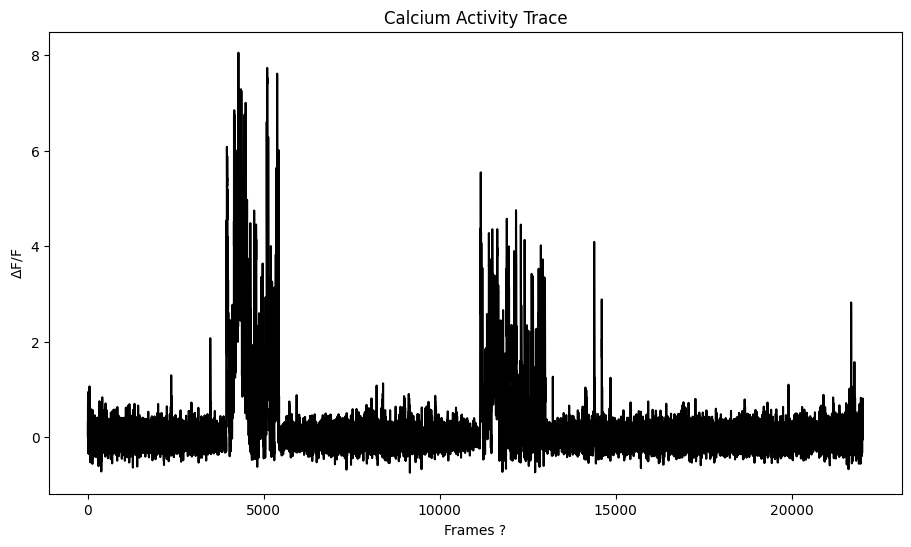

In [14]:
ROI = 20

plt.figure(figsize=(11, 6)) 
plt.plot(dff[:, ROI], 'k')
plt.ylabel(r'$\Delta$F/F')
plt.xlabel('Frames ?')
plt.title('Calcium Activity Trace')

Text(0.5, 1.0, 'Calcium Activity Trace')

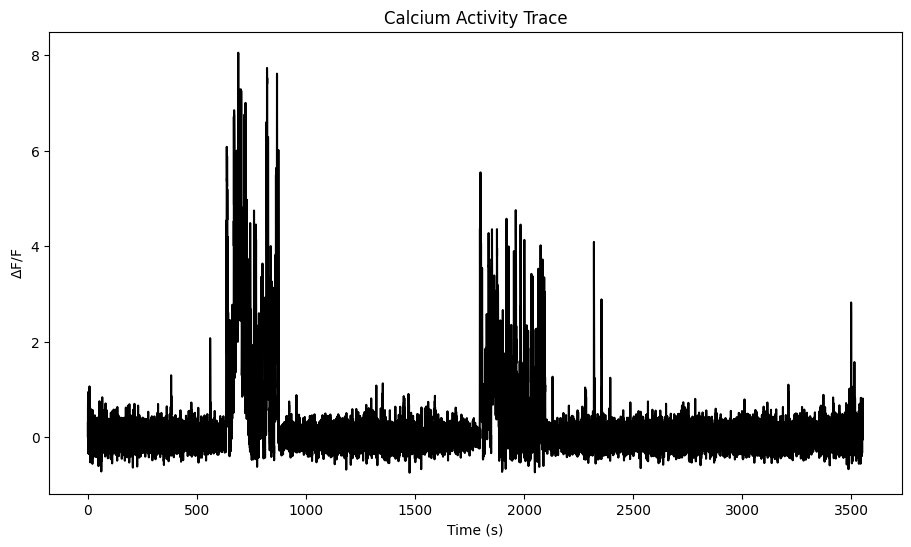

In [15]:
# We have timestamps, if we plot against time, this should roughly match the session duration 
# to do - add session end time to metadata CSVs to get session duration as a sanity check 

# Plot dff for a single ROI against time 
plt.figure(figsize=(11, 6)) 
plt.plot(ts, dff[:, ROI], 'k')
plt.ylabel(r'$\Delta$F/F')
plt.xlabel('Time (s)')
plt.title('Calcium Activity Trace')

In [16]:
# As a sanity check, convert this to time 
print('Session duration:', ts[-1] / 60, 'min')

Session duration: 59.22802816666667 min


In [17]:
# Double check with metadata - 

metadata[metadata.subject_id == 409828][['session_start_time', 'session_end_time']]

,session_start_time,session_end_time
0,12:24:18.963730,13:24:27.772570
1,13:21:39.888000,14:21:12.698880
2,15:10:05.562960,16:09:36.222020
3,13:14:42.634500,14:15:00.029230
4,14:47:35.097180,15:46:50.098970
5,14:02:59.889330,15:02:13.545940
6,11:01:58.469640,12:01:09.403130
7,12:29:05.453040,13:28:34.716700
8,14:40:32.706220,15:39:46.518810
9,10:42:45.603660,11:42:48.293820


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Imaging Rate </h2>

We can calculate the imaging rate from the timestamps (find the median difference between the reported timestamps and take the inverse)

</div>

In [18]:
ts = nwb.processing['plane-3']['dff'].timestamps[:]
dt = np.median(np.diff(ts))

print(f"imaging rate: {1/dt:.2f} Hz")

imaging rate: 6.20 Hz


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> ROIs </h2>

In addition to the timeseries array, the dff container also has an ROI table with spatial information about the detected ROIs. 
</div>

In [19]:
roi_table = nwb.processing['plane-3']['dff'].rois.to_dataframe()
roi_table

,column,volume,plane,roi,pika_roi_id,pika_roi_confidence,is_soma,pixel_mask
id,,,,,,,,
0,2,1,3,0,774392958_0000,0.917422,True,"[[253, 189, 1.0], [254, 189, 1.0], [250, 190, ..."
1,2,1,3,1,774392958_0001,0.915730,True,"[[132, 280, 1.0], [133, 280, 1.0], [131, 281, ..."
2,2,1,3,2,774392958_0002,0.907793,True,"[[153, 123, 1.0], [152, 124, 1.0], [153, 124, ..."
3,2,1,3,3,774392958_0003,0.916637,True,"[[132, 386, 1.0], [133, 386, 1.0], [134, 386, ..."
4,2,1,3,4,774392958_0004,0.914911,True,"[[338, 365, 1.0], [339, 365, 1.0], [340, 365, ..."
...,...,...,...,...,...,...,...,...
160,2,1,3,353,774392958_0353,0.828587,True,"[[11, 323, 1.0], [12, 323, 1.0], [13, 323, 1.0..."
161,2,1,3,435,774392958_0435,0.836927,True,"[[161, 330, 1.0], [162, 330, 1.0], [163, 330, ..."
162,2,1,3,464,774392958_0464,0.916712,True,"[[362, 185, 1.0], [363, 185, 1.0], [364, 185, ..."


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The ROI table</h3>

The `dff` container also carries an **ROI table** (`.rois`), with one row per ROI (region of interest — here, a segmented cell body). The rows line up with the columns of the `dff` array, so row *i* of the ROI table describes the neuron whose trace is column *i* of `dff`.

A few columns are worth knowing:

- `id` — the identifier used to relate the ROI table to the `dff` traces (row ↔ column), both the roi_table and dff are filtered for somas 
- `roi` — original ROI identifier (notice these are not continuous), used to relate the ROIs to the structural data (more on this on the connectomics day) 
- `is_soma` — quality-control flag
- `pixel_mask` — the spatial footprint of the ROI (see Pixel Masks below)
- `pika_roi_id`, `pika_roi_confidence` — identifiers and a confidence score from the segmentation pipeline (“pika” is the internal pipeline name); the raw ids don't carry meaning for analysis

</div>

In [20]:
# Each row represents an ROI

roi_table.shape 


(165, 8)

In [21]:
# Each row relates to a column in dff 
dff.shape

(22030, 165)

In [22]:
roi_table[['roi']]

,roi
id,
0,0
1,1
2,2
3,3
4,4
...,...
160,353
161,435
162,464


In [23]:
roi_table.is_soma.value_counts()

is_soma
True    165
Name: count, dtype: int64

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Pixel Masks </h2>

The pixel masks indicate the spatial location of the ROI masks. This information is useful for quantifying the spatial relationship between the ROIs. 


Here, the information is represented as a sparse array with only the spatial coordinates of the ROIs stored. In other datasets, the structure could be represented as a dense array, with the entire imaging field of view represented.
</div>


In [24]:
print('pixel_mask shape:', np.shape(roi_table.pixel_mask[ROI]))

roi_table.pixel_mask[ROI]

# each row is (x, y, weight) for one pixel belonging to the ROI

pixel_mask shape: (227,)


array([(222, 75, 1.), (223, 75, 1.), (224, 75, 1.), (225, 75, 1.),
       (226, 75, 1.), (227, 75, 1.), (228, 75, 1.), (221, 76, 1.),
       (222, 76, 1.), (223, 76, 1.), (224, 76, 1.), (225, 76, 1.),
       (226, 76, 1.), (227, 76, 1.), (228, 76, 1.), (229, 76, 1.),
       (219, 77, 1.), (220, 77, 1.), (221, 77, 1.), (222, 77, 1.),
       (223, 77, 1.), (224, 77, 1.), (225, 77, 1.), (226, 77, 1.),
       (227, 77, 1.), (228, 77, 1.), (229, 77, 1.), (230, 77, 1.),
       (231, 77, 1.), (218, 78, 1.), (219, 78, 1.), (220, 78, 1.),
       (221, 78, 1.), (222, 78, 1.), (223, 78, 1.), (224, 78, 1.),
       (225, 78, 1.), (226, 78, 1.), (227, 78, 1.), (228, 78, 1.),
       (229, 78, 1.), (230, 78, 1.), (231, 78, 1.), (232, 78, 1.),
       (217, 79, 1.), (218, 79, 1.), (219, 79, 1.), (220, 79, 1.),
       (221, 79, 1.), (222, 79, 1.), (223, 79, 1.), (224, 79, 1.),
       (225, 79, 1.), (226, 79, 1.), (227, 79, 1.), (228, 79, 1.),
       (229, 79, 1.), (230, 79, 1.), (231, 79, 1.), (232, 79, 

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

To plot the masks we need an image of the field of view. These are stored in the *<b>processing/plane-0/images</b>* container.

</div>

In [25]:
nwb.processing['plane-3']['images']

images pynwb.base.Images at 0x139899873855296
Fields:
  description: Summary images of the ophys movie
  images: {
    correlation_projection_denoised_plane-3 <class 'pynwb.image.GrayscaleImage'>,
    max_projection_denoised_plane-3 <class 'pynwb.image.GrayscaleImage'>,
    max_projection_raw_plane-3 <class 'pynwb.image.GrayscaleImage'>,
    mean_projection_denoised_plane-3 <class 'pynwb.image.GrayscaleImage'>,
    mean_projection_raw_plane-3 <class 'pynwb.image.GrayscaleImage'>
  }

max projection shape (H, W): (512, 512)


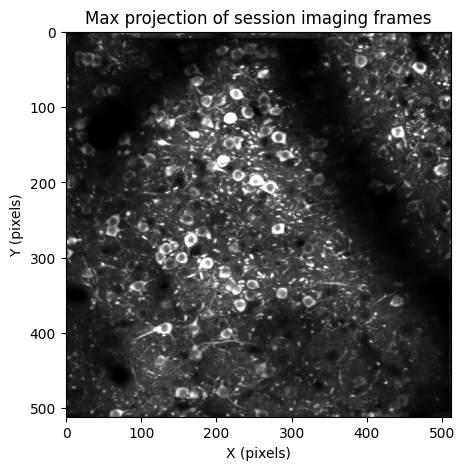

In [26]:
max_projection = nwb.processing['plane-3']['images']['max_projection_denoised_plane-3'].data[:]

vmin, vmax = np.percentile(max_projection, [1, 99])
print('max projection shape (H, W):', max_projection.shape)

plt.figure(figsize=(5, 5))
plt.imshow(max_projection, cmap='gray', origin='upper', aspect='equal', vmin=vmin, vmax=vmax)
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.title('Max projection of session imaging frames')
plt.show()

# change heatmap to log or power scale 

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Now overlay the pixel mask for every ROI on top of the projection image.

</div>

<Figure size 500x500 with 0 Axes>

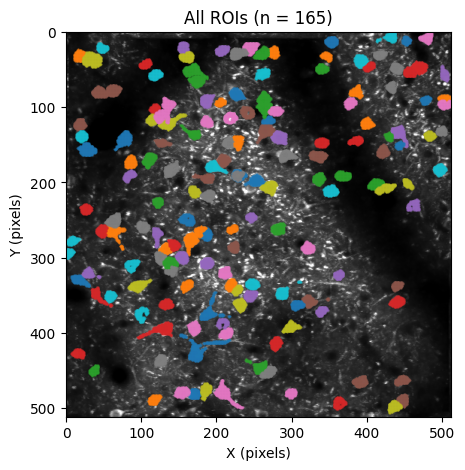

In [27]:
plt.figure(figsize=(5, 5))

vmin, vmax = np.percentile(max_projection, [1, 99])

plt.figure(figsize=(5, 5))
plt.imshow(max_projection, cmap='gray', origin='upper', aspect='equal', vmin=vmin, vmax=vmax)

for pm in roi_table.pixel_mask:
    plt.scatter(pm['x'], pm['y'], s=0.5, alpha=0.5)

plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.title(f'All ROIs (n = {len(roi_table)})')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Let's put the neural activity and the ROI masks together. Index into the columns of dff or the rows of the roi_table to pull data for the same ROI. 

</div>

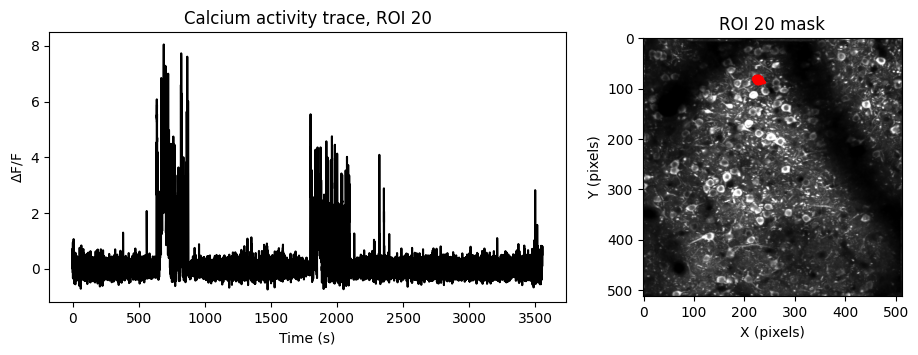

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), width_ratios=[2, 1])


axes[0].plot(ts, dff[:, ROI], color='black')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel(r'$\Delta$F/F')
axes[0].set_title(f'Calcium activity trace, ROI {ROI}')

vmin, vmax = np.percentile(max_projection, [1, 99])
axes[1].imshow(max_projection, cmap='gray', origin='upper', aspect='equal', vmin=vmin, vmax=vmax)
pm = roi_table.pixel_mask[ROI]
axes[1].scatter(pm['x'], pm['y'], s=2, color='red')
axes[1].set_xlabel('X (pixels)')
axes[1].set_ylabel('Y (pixels)')
axes[1].set_title(f'ROI {ROI} mask')

plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Select a different ROI and plots the calcium activity trace and pixel mask. 

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Pause here to document information, code snippets, and figures in the README.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Behavior</h3>

Behavior data is also stored in the *<b>processing</b>* container.

</div>

In [29]:
nwb.processing['behavior']

behavior pynwb.base.ProcessingModule at 0x139901381657088
Fields:
  data_interfaces: {
    eye_tracking <class 'hdmf.common.table.DynamicTable'>,
    running_speed <class 'pynwb.base.TimeSeries'>
  }
  description: processed behavioral data

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Store the behavior data 

Notice that the running speed is an array and the eye tracking data is a table. Let's store both data pieces. 
</div>

In [30]:
running_speed = nwb.processing['behavior']['running_speed'].data[:]
running_ts = nwb.processing['behavior']['running_speed'].timestamps[:]

In [31]:
eye_tracking_table = nwb.processing['behavior']['eye_tracking'].to_dataframe()
eye_tracking_table.head()

,timestamps,cr_area,eye_area,pupil_area,likely_blink,cr_center_x,cr_center_y,cr_width,cr_height,cr_phi,eye_center_x,eye_center_y,eye_width,eye_height,eye_phi,pupil_center_x,pupil_center_y,pupil_width,pupil_height,pupil_phi
id,,,,,,,,,,,,,,,,,,,,
0,0.27302,NaN,NaN,NaN,True,2.814885,4.214959,0.080830,0.076386,1.767222,2.709429,4.466047,NaN,NaN,NaN,2.703789,4.184357,NaN,NaN,NaN
1,0.28849,NaN,NaN,NaN,True,2.822654,4.208316,0.075138,0.071399,1.606827,2.706202,4.446485,NaN,NaN,NaN,2.700774,4.170526,NaN,NaN,NaN
2,0.30324,NaN,NaN,NaN,True,2.834129,4.204885,0.077584,0.072938,0.685785,2.720766,4.454793,NaN,NaN,NaN,2.712850,4.176998,NaN,NaN,NaN
3,0.33603,NaN,NaN,NaN,True,2.841919,4.192760,0.078523,0.065596,0.860045,2.723926,4.422118,NaN,NaN,NaN,2.722756,4.162602,NaN,NaN,NaN
4,0.36925,NaN,NaN,NaN,True,253.396179,373.444000,7.192110,5.902160,93.575150,243.054474,393.775024,NaN,NaN,NaN,243.501099,370.595215,NaN,NaN,NaN


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

The eye tracking table contains many columns. As a behavioral readout to align with the running and neural activity, store one of the columns as an array. 

</div>

In [32]:
# Getting timestamps and pupil area from the eye tracking table 
eye_ts = eye_tracking_table.timestamps.values
pupil_area = eye_tracking_table['pupil_area'].values

In [33]:
print('running_speed:', running_speed.shape, '| running_ts:', running_ts.shape)
print('eye_tracking_table:', eye_tracking_table.shape, '(frames, features)')

running_speed: (209040,) | running_ts: (209040,)
eye_tracking_table: (106463, 20) (frames, features)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Notice how the running speed and eye tracking are different lengths because they were collected at different acquisition rates. Think about why this matters: `dff`, `running_speed`, and the eye-tracking data each have their own length and their own timestamps. If you plotted them against sample number instead of time, they would be misaligned. What is the common variable that lets you put all three on the same axis?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Plot all three streams stacked on a shared time axis. `sharex=True` locks the panels together so the same x window applies to all of them.

</div>

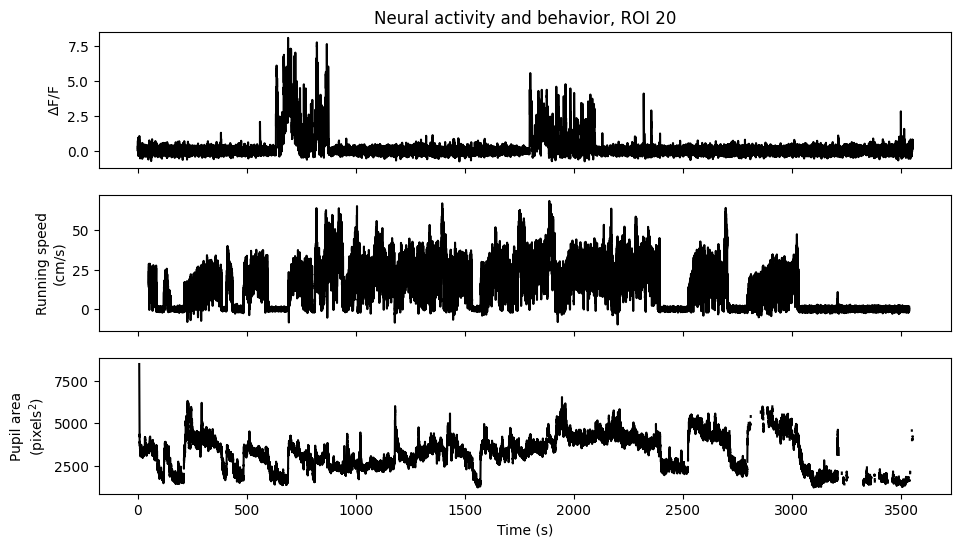

In [34]:
ROI = 20 #reset the ROI index to plot the same ROI as before 

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)

axes[0].plot(ts, dff[:, ROI], color='black')
axes[0].set_ylabel(r'$\Delta$F/F')
axes[0].set_title(f'Neural activity and behavior, ROI {ROI}')

axes[1].plot(running_ts, running_speed, color='black')
axes[1].set_ylabel('Running speed\n(cm/s)') # units are found in the metadata within the NWB file 

axes[2].plot(eye_ts, pupil_area, color='black')
axes[2].set_ylabel('Pupil area\n(pixels$^2$)') # units are found in the metadata within the NWB file 

axes[2].set_xlabel('Time (s)')

plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Pause to discuss the plot. What should we document in the README?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Stimulus information</h3>

During the experiment, the mouse passively viewed a range of visual stimuli. This dataset uses a mix of <b>parametric</b> stimuli (simple, precisely controlled patterns for measuring classic tuning properties) and <b>naturalistic</b> stimuli (images and movies with the richer statistics of the real world). 

The stimuli in this session:

- <b>Drifting gratings (full-field)</b> — a full-screen sinusoidal grating of alternating light and dark bars that moves (drifts) perpendicular to its orientation. Varying the `direction` and `temporal_frequency` probes a neuron's <b>orientation/direction selectivity</b> and preferred speed — the classic way to measure tuning.
- <b>Drifting gratings (windowed)</b> — the same drifting grating, but shown within a small patch of the visual field rather than full-screen. Because it's local, its position (`center_azimuth`, `center_elevation`) matters, which lets it probe <b>where</b> in visual space a neuron responds.
- <b>Locally sparse noise</b> — a grid of randomly placed bright and dark squares on a gray background, changing frame to frame. Averaging activity against the square locations maps a neuron's <b>spatial receptive field</b>. 
- <b>Natural images</b> — photographs of natural scenes, each shown briefly and repeated many times. These probe responses to complex, naturalistic spatial structure rather than a single controlled feature.
- <b>Natural movie</b> — a short natural-scene movie clip repeated many times, probing responses to naturalistic <b>spatiotemporal</b> structure (motion and dynamics over time).
- <b>Spontaneous</b> — a gray screen with no stimulus, used as a <b>baseline</b> to compare against the driven periods.

Epoch and stimulus information is stored in the *<b>intervals</b>* container.<b>Epochs</b> mark the coarse blocks of the session (when each stimulus type was running), while the <b>stimulus table</b> gives trial-by-trial detail (every individual presentation, with its start/stop time and feature values). The actual stimulus images and movie frames live separately in the <b>`stimulus`</b> container. Note - the location of the epoch and stimulus containers can vary across datasets, so we recommend looking quickly across all the containers first. 

</div>

In [35]:
nwb.intervals

{'epochs': epochs pynwb.epoch.TimeIntervals at 0x139901381571312
 Fields:
   colnames: ['stim_name' 'start_time' 'stop_time' 'duration']
   columns: (
     stim_name <class 'hdmf.common.table.VectorData'>,
     start_time <class 'hdmf.common.table.VectorData'>,
     stop_time <class 'hdmf.common.table.VectorData'>,
     duration <class 'hdmf.common.table.VectorData'>
   )
   description: Start and stop times for all stimulus epochs
   id: id <class 'hdmf.common.table.ElementIdentifiers'>,
 'stimulus_table': stimulus_table pynwb.epoch.TimeIntervals at 0x139899871062368
 Fields:
   colnames: ['stim_name' 'start_time' 'stop_time' 'temporal_frequency'
  'spatial_frequency' 'center_azimuth' 'center_elevation' 'direction'
  'frame' 'image_order' 'image_index' 'stimulus_condition_id']
   columns: (
     stim_name <class 'hdmf.common.table.VectorData'>,
     start_time <class 'hdmf.common.table.VectorData'>,
     stop_time <class 'hdmf.common.table.VectorData'>,
     temporal_frequency <class 'hdmf.common.table.VectorData'>,
     spatial_frequency <class 'hdmf.common.table.VectorData'>,
     center_azimuth <class 'hdmf.common.table.VectorData'>,
     center_elevation <class 'hdmf.common.table.VectorData'>,
     direction <class 'hdmf.common.table.VectorData'>,
     frame <class 'hdmf.common.table.VectorData'>,
     image_order <class 'hdmf.common.table.VectorData'>,
     image_index <class 'hdmf.common.table.VectorData'>,
     stimulus_condition_id <class 'hdmf.common.table.VectorData'>
   )
   description: Trial times & parameters all stimulus
   id: id <class 'hdmf.common.table.ElementIdentifiers'>}

In [36]:
# Epochs table 
epochs = nwb.intervals['epochs'].to_dataframe()
epochs 

,stim_name,start_time,stop_time,duration
id,,,,
0,drifting_gratings_full,52.851639,340.074066,287.222412
1,drifting_gratings_windowed,343.093262,630.315857,287.222595
2,locally_sparse_noise,633.335022,873.551819,240.216797
3,spontaneous,874.536011,1174.769409,300.233398
4,natural_images_12,1177.788696,1329.898682,152.109985
5,natural_movie,1341.925293,1792.283813,450.358521
6,locally_sparse_noise,1796.337280,2096.453857,300.116577
7,natural_images,2098.555664,2397.721436,299.165771
8,drifting_gratings_windowed,2412.817383,2700.039795,287.222412


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Let's add the epoch information to the timeseries plots. 

In [37]:
# Function to shade different epochs and different color 
names = epochs.stim_name.unique()
colors = dict(zip(names, plt.cm.tab10.colors))


def shade_epochs(ax):
    """Shade each epoch on ax, one color per stimulus name."""
    for name in names:
        stim = epochs[epochs.stim_name == name]

        for i, (start, stop) in enumerate(zip(stim.start_time, stim.stop_time)):
            ax.axvspan(start, stop,
                       color=colors[name],
                       alpha=0.3,
                       label=name if i == 0 else None)   # label only the first

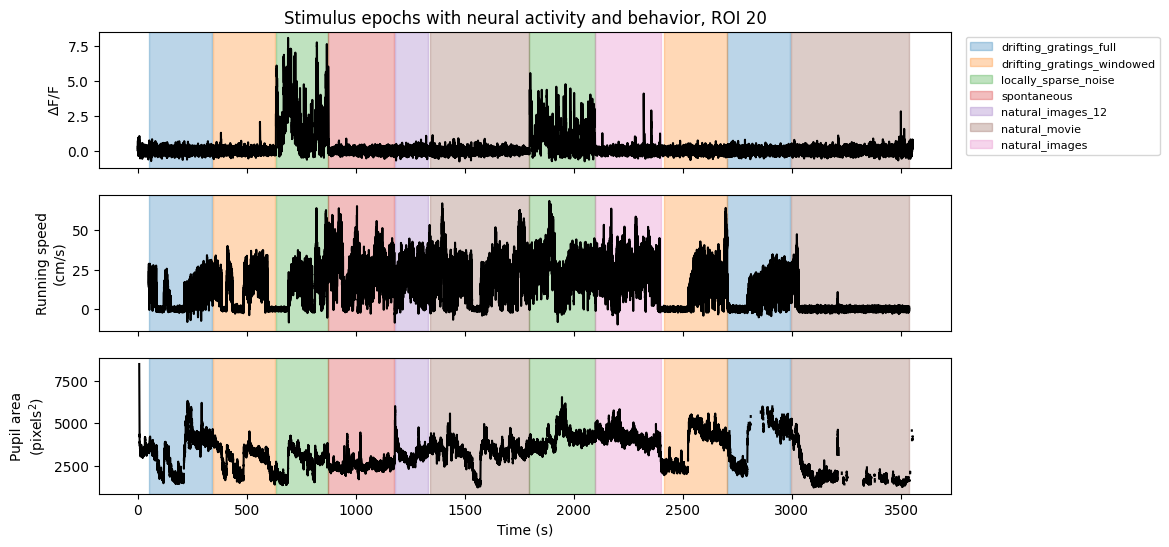

In [38]:
# Setup figure 
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)

# Plot neural activity 
axes[0].plot(ts, dff[:, ROI], color='black')
axes[0].set_ylabel(r'$\Delta$F/F')
axes[0].set_title(f'Stimulus epochs with neural activity and behavior, ROI {ROI}')

# Plot running speed 
axes[1].plot(running_ts, running_speed, color='black')
axes[1].set_ylabel('Running speed\n(cm/s)')

# Plot pupil area 
axes[2].plot(eye_ts, pupil_area, color='black')
axes[2].set_ylabel('Pupil area\n(pixels$^2$)')
axes[2].set_xlabel('Time (s)')

# Add epoch shading 
for ax in axes:
    shade_epochs(ax)

# Add legend 
axes[0].legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)

plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

What do you notice about the plots above?

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Let's zoom in on one of the epochs during which this neuron was particularly active. 

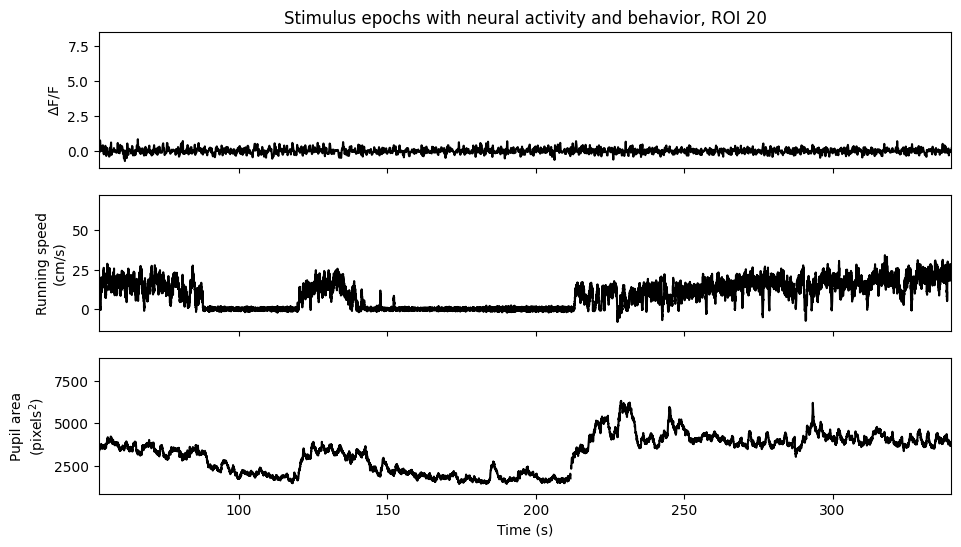

In [39]:
# Define epoch window to plot 
drifting_gratings_full = epochs[epochs.stim_name == 'drifting_gratings_full'].iloc[0] # Get first epoch 

# Setup figure 

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)

# Plot neural activity 
axes[0].plot(ts, dff[:, ROI], color='black')
axes[0].set_ylabel(r'$\Delta$F/F')
axes[0].set_title(f'Stimulus epochs with neural activity and behavior, ROI {ROI}')

# Plot running speed 
axes[1].plot(running_ts, running_speed, color='black')
axes[1].set_ylabel('Running speed\n(cm/s)')

# Plot pupil area 
axes[2].plot(eye_ts, pupil_area, color='black')
axes[2].set_ylabel('Pupil area\n(pixels$^2$)')
axes[2].set_xlabel('Time (s)')

axes[0].set_xlim(drifting_gratings_full.start_time, drifting_gratings_full.stop_time) 
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Stimulus Table </h2> 
The stimulus table contains more detailed information about the stimulus conditions. Each row represents a single stimulus representation, with start/stop times and other information about the stimulus. 

As with the metadata and ROI tables, scan the stimulus table's columns and flag any you don't recognize. Different stimulus types use different feature columns (described just below), so expect some columns to be empty for a given stimulus.

</div>

In [40]:
stimulus_table = nwb.intervals['stimulus_table'].to_dataframe()
stimulus_table

,stim_name,start_time,stop_time,temporal_frequency,spatial_frequency,center_azimuth,center_elevation,direction,frame,image_order,image_index,stimulus_condition_id
id,,,,,,,,,,,,
0,drifting_gratings_full,52.851639,54.836639,1.0,0.08,0.0,0.0,300.0,NaN,NaN,NaN,22
1,drifting_gratings_full,55.854118,57.839161,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,24
2,drifting_gratings_full,58.856628,60.841621,1.0,0.04,0.0,0.0,300.0,NaN,NaN,NaN,10
3,drifting_gratings_full,61.859138,63.844120,1.0,0.04,0.0,0.0,240.0,NaN,NaN,NaN,8
4,drifting_gratings_full,64.861656,66.846611,1.0,0.08,0.0,0.0,330.0,NaN,NaN,NaN,23
...,...,...,...,...,...,...,...,...,...,...,...,...
33209,natural_movie,3535.585693,3535.602295,NaN,NaN,NaN,NaN,NaN,895.0,NaN,NaN,2668
33210,natural_movie,3535.618896,3535.635742,NaN,NaN,NaN,NaN,NaN,896.0,NaN,NaN,2669
33211,natural_movie,3535.652344,3535.668945,NaN,NaN,NaN,NaN,NaN,897.0,NaN,NaN,2670


In [41]:
stimulus_table.columns

Index(['stim_name', 'start_time', 'stop_time', 'temporal_frequency',
       'spatial_frequency', 'center_azimuth', 'center_elevation', 'direction',
       'frame', 'image_order', 'image_index', 'stimulus_condition_id'],
      dtype='object')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

#### Plot responses with stimulus presentation times overlaid  

The neuron was active at some parts of the epoch but not others, likely aligned with different stimuli presentations. We can add information from the stimulus table, such as the start and end times of each stimulus presentation to see how the neural activity aligns with the stimuli within this epoch. 

</div>

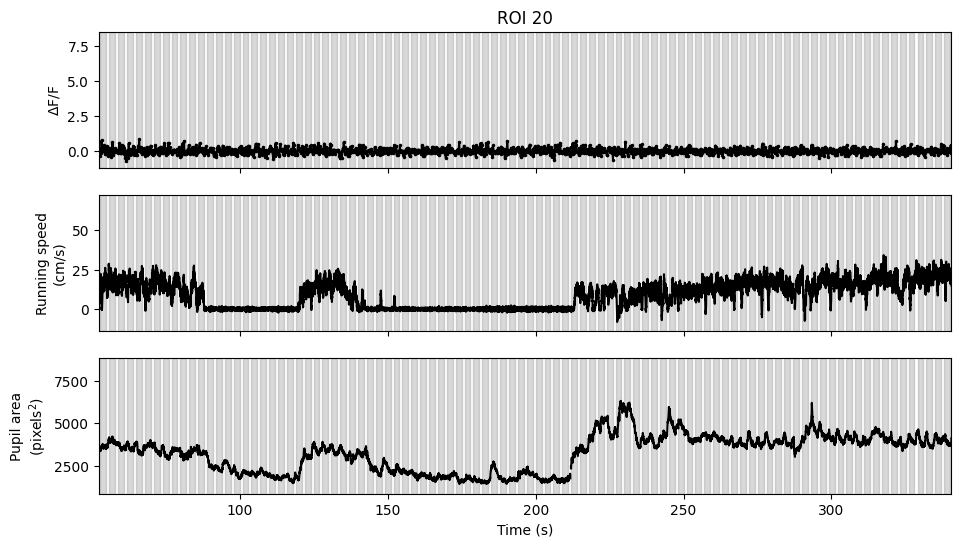

In [42]:
drifting_gratings_full_stimulus = stimulus_table[(stimulus_table.stim_name == 'drifting_gratings_full') \
                                & (stimulus_table.start_time <= epochs[epochs.stim_name == 'drifting_gratings_full'].stop_time.values[0])]
presentations = drifting_gratings_full_stimulus 
pad = 0.5

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)

axes[0].plot(ts, dff[:, ROI], color='black', marker='.', markersize=3)
axes[0].set_ylabel(r'$\Delta$F/F')
axes[0].set_title(f'ROI {ROI}')

axes[1].plot(running_ts, running_speed, color='black')
axes[1].set_ylabel('Running speed\n(cm/s)')

axes[2].plot(eye_ts, pupil_area, color='black')
axes[2].set_ylabel('Pupil area\n(pixels$^2$)')
axes[2].set_xlabel('Time (s)')

# Shade all presentations 
for ax in axes:
    for _, pres in presentations.iterrows():
        ax.axvspan(pres.start_time, pres.stop_time, color='gray', alpha=0.3)

# Set xlim to span all presentations
axes[0].set_xlim(presentations.iloc[0].start_time - pad, 
                 presentations.iloc[-1].stop_time + pad)

plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Stimulus features</h3>

Beyond start/stop times, each stimulus type has its own filled feature columns in the stimulus table. Which columns are meaningful depends on the stimulus:

- **drifting_gratings_full** — `temporal_frequency`, `spatial_frequency`, `direction`
- **drifting_gratings_windowed** — same as full, plus `center_azimuth`, `center_elevation` (the grating covers only part of the visual field, so its position matters)
- **locally_sparse_noise** — `frame` (indexes the noise frame shown)
- **natural_images** — `image_order`, `image_index` (which image, and its order)
- **natural_movie** — `frame` (frame number within the movie)
- **spontaneous** — none (no stimulus; a gray-screen baseline period)

For `natural_images`, `natural_movie`, and `locally_sparse_noise`, these numbers index into the actual stimulus images stored in the NWB `stimulus` container, which we look at below. See the databook's [stimulus reference](https://allenswdb.github.io/physiology/ophys/V1DD/V1DD-stimuli.html) for details and examples.

</div>

In [43]:
stimulus_table[stimulus_table.stim_name == 'drifting_gratings_full']

,stim_name,start_time,stop_time,temporal_frequency,spatial_frequency,center_azimuth,center_elevation,direction,frame,image_order,image_index,stimulus_condition_id
id,,,,,,,,,,,,
0,drifting_gratings_full,52.851639,54.836639,1.0,0.08,0.0,0.0,300.0,NaN,NaN,NaN,22
1,drifting_gratings_full,55.854118,57.839161,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,24
2,drifting_gratings_full,58.856628,60.841621,1.0,0.04,0.0,0.0,300.0,NaN,NaN,NaN,10
3,drifting_gratings_full,61.859138,63.844120,1.0,0.04,0.0,0.0,240.0,NaN,NaN,NaN,8
4,drifting_gratings_full,64.861656,66.846611,1.0,0.08,0.0,0.0,330.0,NaN,NaN,NaN,23
...,...,...,...,...,...,...,...,...,...,...,...,...
17009,drifting_gratings_full,2976.286621,2978.271484,1.0,0.08,0.0,0.0,0.0,NaN,NaN,NaN,12
17010,drifting_gratings_full,2979.289062,2981.274170,1.0,0.08,0.0,0.0,60.0,NaN,NaN,NaN,14
17011,drifting_gratings_full,2982.291504,2984.276611,1.0,0.04,0.0,0.0,180.0,NaN,NaN,NaN,6


In [44]:
stimulus_table[stimulus_table.stim_name == 'drifting_gratings_windowed'].head()

# window, so define the position with center_azimuth and center_elevation in addition to temporal_frequency, spatial_frequency, direction 

,stim_name,start_time,stop_time,temporal_frequency,spatial_frequency,center_azimuth,center_elevation,direction,frame,image_order,image_index,stimulus_condition_id
id,,,,,,,,,,,,
96,drifting_gratings_windowed,343.093262,345.078278,1.0,0.04,-19.6,-10.0,240.0,NaN,NaN,NaN,33
97,drifting_gratings_windowed,346.095795,348.080780,1.0,0.08,-19.6,-10.0,120.0,NaN,NaN,NaN,41
98,drifting_gratings_windowed,349.098267,351.083282,1.0,0.04,-19.6,-10.0,120.0,NaN,NaN,NaN,29
99,drifting_gratings_windowed,352.100769,354.085785,1.0,0.04,-19.6,-10.0,300.0,NaN,NaN,NaN,35
100,drifting_gratings_windowed,355.103271,357.088257,1.0,0.08,-19.6,-10.0,240.0,NaN,NaN,NaN,45


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Natural Images and Natural Movies 

These image_index and frame numbers reference stimulus images that are stored in the /stimulus container of the nwb
</div>

In [45]:
natural_images = stimulus_table[stimulus_table.stim_name == 'natural_images']
natural_images.head()

# Here the image order relates to the images in the stimulus container 
# question - what is image index?  

,stim_name,start_time,stop_time,temporal_frequency,spatial_frequency,center_azimuth,center_elevation,direction,frame,image_order,image_index,stimulus_condition_id
id,,,,,,,,,,,,
15878,natural_images,2098.555664,2098.855957,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1643
15879,natural_images,2098.872559,2099.172852,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1644
15880,natural_images,2099.189453,2099.489746,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,1645
15881,natural_images,2099.506348,2099.806641,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,1646
15882,natural_images,2099.823242,2100.123535,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,1647


In [46]:
len(natural_images.image_index.unique())

118

In [47]:
# nwb.stimulus['natural_images']

In [48]:
len(nwb.stimulus['natural_images'].images)

118

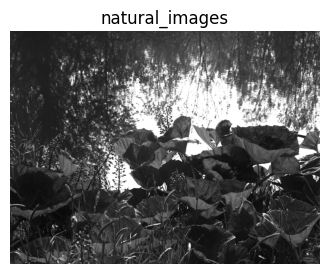

In [49]:
plt.figure(figsize=(4, 4))
plt.imshow(nwb.stimulus['natural_images']['100'], cmap='gray')
plt.axis('off')
plt.title('natural_images')
plt.show()


In [50]:
natural_movie = stimulus_table[stimulus_table.stim_name == 'natural_movie']
natural_movie.head()

# the frame relates to the frame number in the movie, which is stored in the stimulus container 

,stim_name,start_time,stop_time,temporal_frequency,spatial_frequency,center_azimuth,center_elevation,direction,frame,image_order,image_index,stimulus_condition_id
id,,,,,,,,,,,,
1431,natural_movie,1341.925293,1341.942017,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,1773
1432,natural_movie,1341.958618,1341.975342,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1774
1433,natural_movie,1341.992065,1342.008667,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,1775
1434,natural_movie,1342.025391,1342.042114,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,1776
1435,natural_movie,1342.058716,1342.075562,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,1777


In [51]:
natural_movie.frame.nunique()

3600

In [52]:
len(nwb.stimulus['natural_movie'].images)

3600

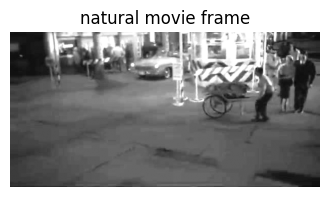

In [53]:
plt.figure(figsize=(4, 4))
plt.imshow(nwb.stimulus['natural_movie']['1500'], cmap='gray')
plt.axis('off')
plt.title('natural movie frame')
plt.show()


In [54]:
stimulus_table[stimulus_table.stim_name == 'locally_sparse_noise'].head()

# same for locally sparse noise 

,stim_name,start_time,stop_time,temporal_frequency,spatial_frequency,center_azimuth,center_elevation,direction,frame,image_order,image_index,stimulus_condition_id
id,,,,,,,,,,,,
192,locally_sparse_noise,633.335022,633.635254,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,50
193,locally_sparse_noise,633.651978,633.952209,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,51
194,locally_sparse_noise,633.968872,634.269165,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,52
195,locally_sparse_noise,634.285828,634.586060,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,53
196,locally_sparse_noise,634.602783,634.903015,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,54


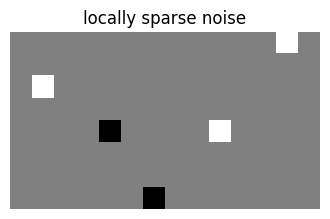

In [55]:
plt.figure(figsize=(4, 4))
plt.imshow(nwb.stimulus['locally_sparse_noise']['10'], cmap='gray')
plt.axis('off')
plt.title('locally sparse noise')
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Stimulus Condition ID</h3>

Each **unique stimulus condition** is assigned a `stimulus_condition_id`. Repeated presentations of the same condition share the same id, so this column is what you group on to collect all the trials of a given stimulus (for example, when averaging responses across repeats). It also lets you line up the same condition across sessions.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

What information can you find by querying the stimulus table? 

</div>

In [56]:
# # Examples 

# # How many presentations of each stimulus type were there? 

# stimulus_table.stim_name.value_counts()

# # could also use: stimulus_table.groupby('stim_name').size()

# # How many unique stimuli were presented within each stimuli type? 
# stimulus_table.groupby('stim_name')['stimulus_condition_id'].nunique()

# # How many times were each individual sitmulus presented? For simplicity, look at just the natural images. 
# natural = stimulus_table[stimulus_table.stim_name == 'natural_images']

# natural.stimulus_condition_id.value_counts()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Below, we'll use the stimulus condition id to shade each stimulus presentation a different color in our timeseries plot from above. 

</div>


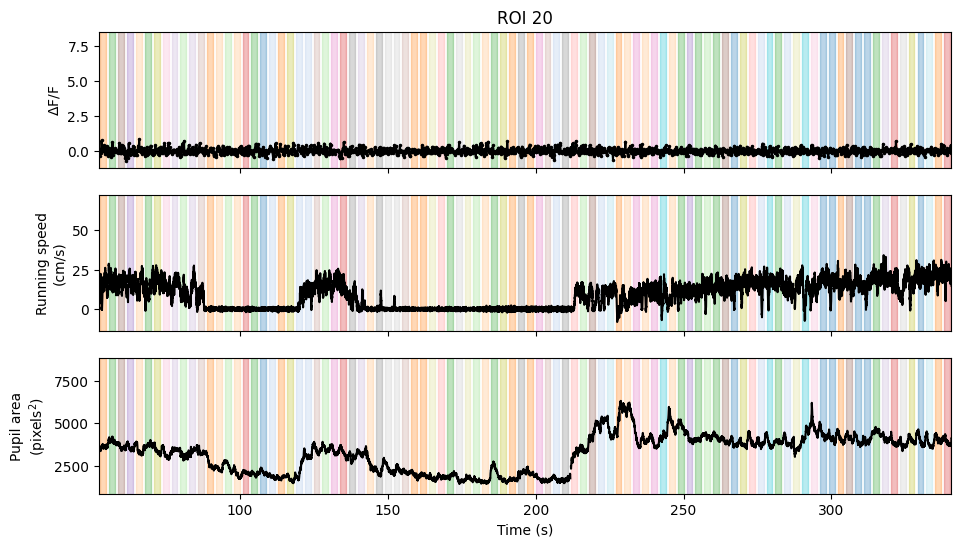

In [57]:
drifting_gratings_full_stimulus = stimulus_table[(stimulus_table.stim_name == 'drifting_gratings_full') \
                                & (stimulus_table.start_time <= epochs[epochs.stim_name == 'drifting_gratings_full'].stop_time.values[0])]
presentations = drifting_gratings_full_stimulus
pad = 0.5

# Map each condition_id to a color
unique_conditions = sorted(presentations.stimulus_condition_id.unique())
cmap = plt.cm.tab20
condition_colors = {cond: cmap(i % 20 / 20) for i, cond in enumerate(unique_conditions)}

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)

axes[0].plot(ts, dff[:, ROI], color='black', marker='.', markersize=3)
axes[0].set_ylabel(r'$\Delta$F/F')
axes[0].set_title(f'ROI {ROI}')

axes[1].plot(running_ts, running_speed, color='black')
axes[1].set_ylabel('Running speed\n(cm/s)')

axes[2].plot(eye_ts, pupil_area, color='black')
axes[2].set_ylabel('Pupil area\n(pixels$^2$)')
axes[2].set_xlabel('Time (s)')

# Shade by condition color
for ax in axes:
    for _, pres in presentations.iterrows():
        color = condition_colors[pres.stimulus_condition_id]
        ax.axvspan(pres.start_time, pres.stop_time, color=color, alpha=0.3)

axes[0].set_xlim(presentations.iloc[0].start_time - pad,
                 presentations.iloc[-1].stop_time + pad)

plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise — README checkpoint:** You've now seen neural activity, behavior, and stimulus information for this session. Update your README with what you've learned about the stimulus table (the stimulus types, key feature columns, and how `stimulus_condition_id` groups repeats), and note any remaining columns or terms you still need to look up.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Part 4b: Create summary plots</h2>

This neuron seems to respond to a few particular stimuli. Perhaps there are repeated trials of the same stimuli. Which stimuli are the neurons most responsive to? To start answering this question, we want to see the neurons' averaged responses to repeated stimuli and compare across stimuli. 

First, we need to take a list of stimulus times and pull out a window of data around each one, then average across the windows. We've written a function below for aligning timeseries data to events. We can reuse this for neural activity, running, and pupil area.

</div>

In [58]:
def align_to_events(data, timestamps, event_times, pre=0.5, post=1.5):
    """Cut a window of data around each event time.

    data        : array with time along the first axis
    timestamps  : times for each row of data, in seconds
    event_times : times to align to, in seconds
    pre, post   : seconds before and after each event

    Returns (windows, t) where t is the time axis in seconds
    relative to the event, and windows has one entry per event.
    """
    dt = np.median(np.diff(timestamps))
    n_pre, n_post = int(pre / dt), int(post / dt)

    windows = []
    for event_time in event_times:
        i = np.searchsorted(timestamps, event_time)

        # skip events too close to the start or end of the recording
        if i - n_pre >= 0 and i + n_post <= len(timestamps):
            windows.append(data[i - n_pre:i + n_post])

    t = np.arange(-n_pre, n_post) * dt
    return np.array(windows), t


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

#### Trial-averaged response for one ROI

</div>

windows shape (n_presentations, n_frames): (8, 9)


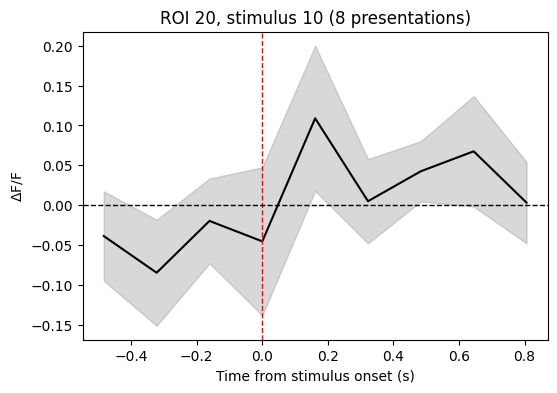

In [59]:
stimulus_id = drifting_gratings_full_stimulus.stimulus_condition_id.iloc[2] # select a single stimulus

trace = np.asarray(dff[:, ROI])
onsets = stimulus_table[stimulus_table.stimulus_condition_id == stimulus_id].start_time.values

windows, t = align_to_events(trace, ts, onsets, pre=0.5, post=1.0)
print('windows shape (n_presentations, n_frames):', windows.shape)

mean = np.nanmean(windows, axis=0)
sem  = np.nanstd(windows, axis=0) / np.sqrt(np.sum(~np.isnan(windows), axis=0))

plt.figure(figsize=(6, 4))
plt.plot(t, mean, color='black')
plt.fill_between(t, mean - sem, mean + sem, color='gray', alpha=0.3)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.xlabel('Time from stimulus onset (s)')
plt.ylabel(r'$\Delta$F/F')
plt.title(f'ROI {ROI}, stimulus {stimulus_id} ({len(windows)} presentations)')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

#### Neural activity and behavior aligned to the same stimulus

The same function applied to all three streams. 
</div>

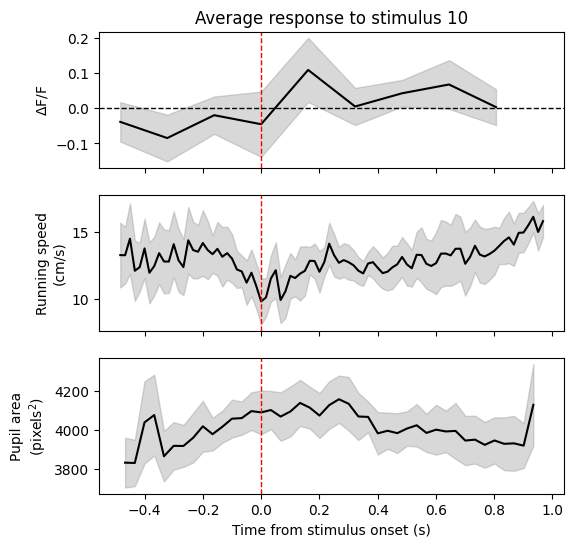

In [60]:
streams = [
    (np.asarray(dff[:, ROI]), ts, r'$\Delta$F/F'),
    (running_speed, running_ts, 'Running speed\n(cm/s)'),
    (pupil_area, eye_ts, 'Pupil area\n(pixels$^2$)'),
]

fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

for ax, (data, timestamps, label) in zip(axes, streams):
    windows, t = align_to_events(data, timestamps, onsets, pre=0.5, post=1.0)
    mean = np.nanmean(windows, axis=0) 
    sem  = np.nanstd(windows, axis=0) / np.sqrt(np.sum(~np.isnan(windows), axis=0))

    ax.plot(t, mean, color='black')
    ax.fill_between(t, mean - sem, mean + sem, color='gray', alpha=0.3)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)   
    if ax == axes[0]:
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel(label)
    
axes[0].set_title(f'Average response to stimulus {stimulus_id}')
axes[2].set_xlabel('Time from stimulus onset (s)')

plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

#### Summary plot: responses of several neurons to a single stimuli 

</div>

roi_responses shape (n_rois, n_timepoints): (99, 9)


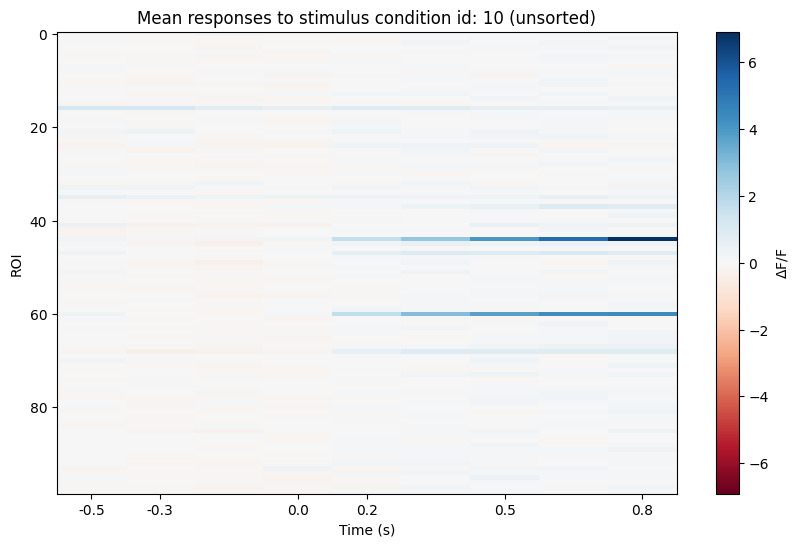

In [61]:
stimulus_id = drifting_gratings_full_stimulus.stimulus_condition_id.iloc[2]
onsets = stimulus_table[stimulus_table.stimulus_condition_id == stimulus_id].start_time.values

n_rois = 99
dff_subset = dff[:, :n_rois]

roi_responses = []
for roi in range(n_rois):
    trace = np.asarray(dff_subset[:, roi])
    windows, t = align_to_events(trace, ts, onsets, pre=0.5, post=1.0)
    roi_responses.append(windows.mean(axis=0))  # average across presentations

roi_responses = np.array(roi_responses)  # (n_rois, n_timepoints)
print('roi_responses shape (n_rois, n_timepoints):', roi_responses.shape)

plt.figure(figsize=(10, 6))
plt.imshow(roi_responses, aspect='auto', cmap='RdBu',
           vmin=-np.abs(roi_responses).max(), vmax=np.abs(roi_responses).max())
plt.colorbar(label=r'$\Delta$F/F')

# Set x ticks to show actual time values
tick_positions = np.linspace(0, len(t) - 1, 6).astype(int)
plt.xticks(tick_positions, np.round(t[tick_positions], 1))
plt.xlabel('Time (s)')
plt.ylabel('ROI')
plt.title(f'Mean responses to stimulus condition id: {stimulus_id} (unsorted)')
plt.show()

roi_responses shape (n_rois, n_timepoints): (99, 9)


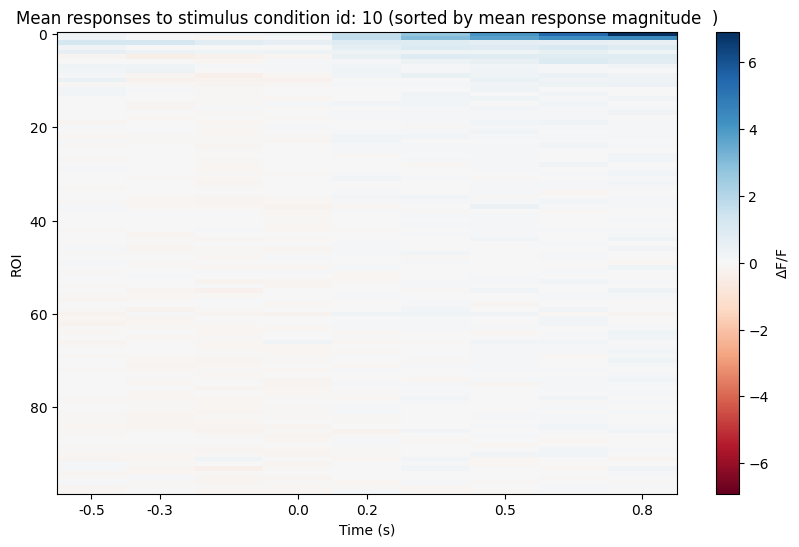

In [62]:
# Add some sorting, like by the magnitude of the mean response across ROIs 

stimulus_id = drifting_gratings_full_stimulus.stimulus_condition_id.iloc[2]
onsets = stimulus_table[stimulus_table.stimulus_condition_id == stimulus_id].start_time.values

n_rois = 99
dff_subset = dff[:, :n_rois]

roi_responses = []
for roi in range(n_rois):
    trace = np.asarray(dff_subset[:, roi])
    windows, t = align_to_events(trace, ts, onsets, pre=0.5, post=1.0)
    roi_responses.append(windows.mean(axis=0))  # average across presentations

roi_responses = np.array(roi_responses)  # (n_rois, n_timepoints)
print('roi_responses shape (n_rois, n_timepoints):', roi_responses.shape)

plt.figure(figsize=(10, 6))
mean_magnitude = roi_responses.mean(axis=1)  # mean response across time for each ROI
sort_order = np.argsort(mean_magnitude)[::-1]  # descending: strongest responders first
roi_responses_sorted = roi_responses[sort_order]
plt.imshow(roi_responses_sorted, aspect='auto', cmap='RdBu',
           vmin=-np.abs(roi_responses_sorted).max(), vmax=np.abs(roi_responses_sorted).max())
plt.imshow(roi_responses_sorted, aspect='auto', cmap='RdBu',
           vmin=-np.abs(roi_responses_sorted).max(), vmax=np.abs(roi_responses_sorted).max())
plt.colorbar(label=r'$\Delta$F/F')

# Set x ticks to show actual time values
tick_positions = np.linspace(0, len(t) - 1, 6).astype(int)
plt.xticks(tick_positions, np.round(t[tick_positions], 1))
plt.xlabel('Time (s)')
plt.ylabel('ROI')
plt.title(f'Mean responses to stimulus condition id: {stimulus_id} (sorted by mean response magnitude  )')
plt.show() 

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Discussion & wrap-up</h2>

You've walked the full path for one session: formed expectations, explored the file's structure and vocabulary, extracted neural, behavioral, and stimulus data, and built visualizations from single traces up to trial-averaged summaries.

Discuss as a group:

- What scientific questions can you ask with this dataset?
- What are its limitations — what can't it tell you?
- Which columns or terms are still unclear? Where would you look them up?

Finally, make a last pass over your README so it stands on its own: someone else should be able to read it and understand what this dataset contains and how to get started, without opening the NWB file.

</div>
